In [48]:
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import omicverse as ov
from pathlib import Path
from tqdm import tqdm

In [8]:
import matplotlib
import matplotlib_inline
import IPython

print("matplotlib:", matplotlib.__version__)
print("matplotlib_inline:", matplotlib_inline.__version__)
print("IPython:", IPython.__version__)
print("backend:", matplotlib.get_backend())

matplotlib: 3.10.8
matplotlib_inline: 0.1.7
IPython: 8.28.0
backend: module://matplotlib_inline.backend_inline


In [49]:
def run_umap(adata,nfeatures=2000,batch_key = None,min_dist = 0.3,n_neighbors = 15,n_pcs=20):
    adata.raw = adata.copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, n_top_genes=nfeatures, subset=True)
    sc.pp.scale(adata)
    sc.tl.pca(adata, svd_solver='arpack')
    if batch_key is None: 
        sc.pp.neighbors(adata, use_rep='X_pca',n_neighbors=n_neighbors, n_pcs=n_pcs)
    else: 
        sc.external.pp.harmony_integrate(adata, batch_key,basis = 'X_pca',max_iter_harmony = 20)
        sc.pp.neighbors(adata, use_rep='X_pca_harmony',n_neighbors=n_neighbors, n_pcs=n_pcs)
    sc.tl.umap(adata,min_dist=min_dist)
    return(adata)

In [50]:
adata = sc.read_h5ad('h5ad/islet_QC.h5ad')

In [51]:
adata = run_umap(adata,batch_key='sample_name')

2026-03-04 09:44:15,043 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-03-04 09:44:24,444 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-03-04 09:44:24,896 - harmonypy - INFO - Iteration 1 of 20
2026-03-04 09:45:01,282 - harmonypy - INFO - Iteration 2 of 20
2026-03-04 09:45:39,328 - harmonypy - INFO - Iteration 3 of 20
2026-03-04 09:46:08,511 - harmonypy - INFO - Iteration 4 of 20
2026-03-04 09:46:39,102 - harmonypy - INFO - Iteration 5 of 20
2026-03-04 09:47:03,737 - harmonypy - INFO - Converged after 5 iterations


In [52]:
sc.tl.leiden(adata, resolution=0.5)

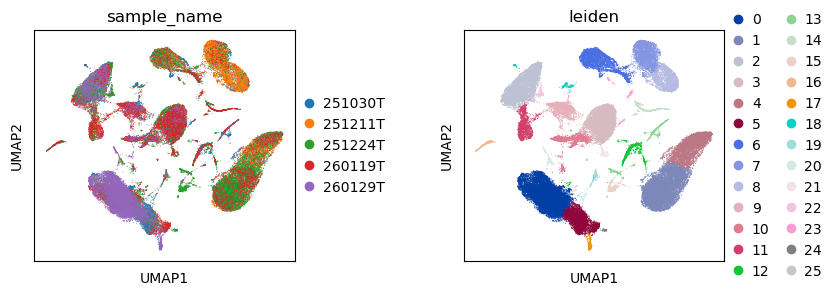

In [53]:
with plt.rc_context({'figure.figsize': (3, 3)}):
    sc.pl.umap(adata,color=['sample_name','leiden'],wspace=0.5)

In [54]:
adata.write_h5ad('h5ad/islet_raw_umap.h5ad',compression='gzip')

In [2]:
adata = sc.read_h5ad('h5ad/islet_raw_umap.h5ad')

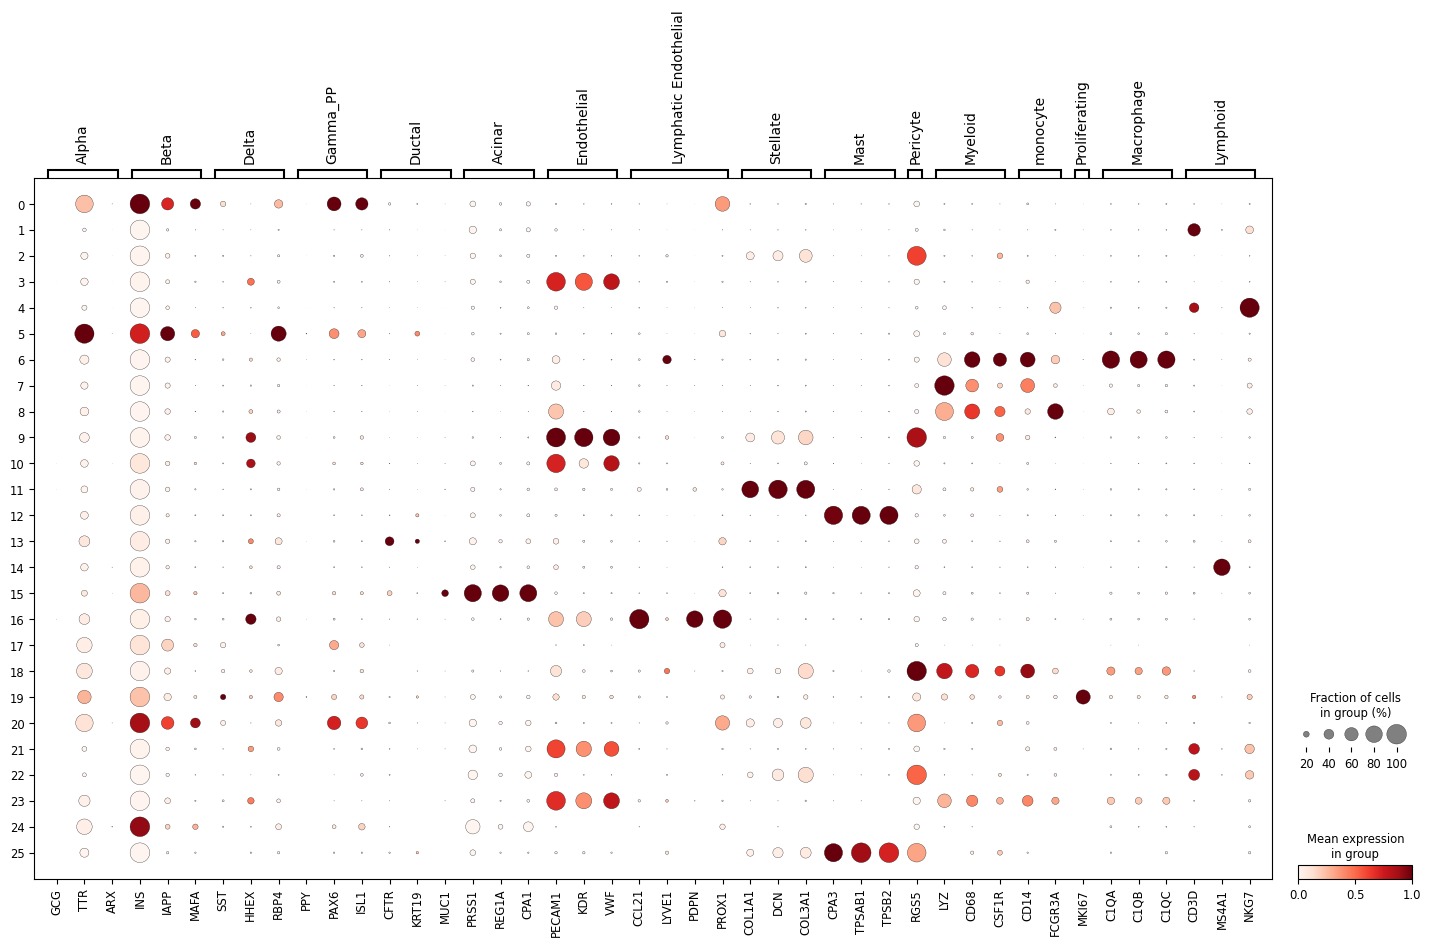

In [86]:
pancreas_markers = {
    "Alpha": ["GCG", "TTR", "ARX"],
    "Beta": ["INS", "IAPP", "MAFA"],
    "Delta": ["SST", "HHEX", "RBP4"],
    "Gamma_PP": ["PPY", "PAX6", "ISL1"],
    "Ductal": ["CFTR", "KRT19", "MUC1"],
    "Acinar": ["PRSS1", "REG1A", "CPA1"],
    "Endothelial": ["PECAM1", "KDR", "VWF"],
    "Lymphatic Endothelial":["CCL21", "LYVE1", "PDPN", "PROX1"],
    "Stellate": ["COL1A1", "DCN", "COL3A1"],
    "Mast":["CPA3", "TPSAB1", "TPSB2"],
    'Pericyte':['RGS5'],
    "Myeloid": ["LYZ", "CD68", "CSF1R"],
    'monocyte':['CD14','FCGR3A'],
    'Proliferating': ["MKI67"],
    "Macrophage": ["C1QA", "C1QB", "C1QC"],
    "Lymphoid": ["CD3D", "MS4A1", "NKG7"]
}

sc.pl.dotplot(
    adata, pancreas_markers, 
    groupby='leiden',
    standard_scale='var')

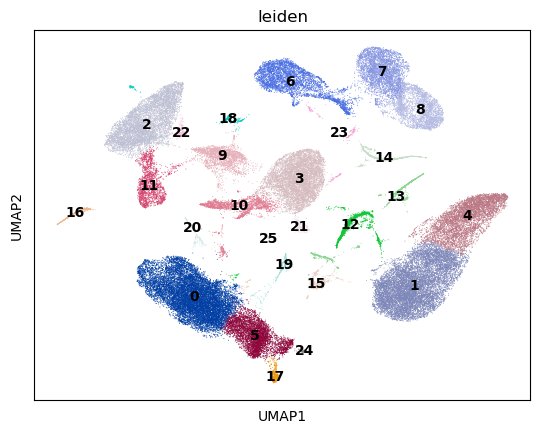

In [56]:
sc.pl.umap(adata,color=['leiden'],legend_loc='on data')

In [63]:
adata = adata.raw.to_adata()
adata.raw = adata.copy()

In [64]:
adata.X.max()

17387.0

In [65]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.tl.rank_genes_groups(adata, 'leiden',  method='t-test',use_raw=False,key_added='leiden_ttest')
leiden_top5_genes = {
    leiden: adata.uns['leiden_ttest']['names'][leiden][:10].tolist()
    for leiden in adata.uns['leiden_ttest']['names'].dtype.names
}

In [92]:
leiden_ct = {
    "Beta": [0,5,17,24],
    "Acinar": [15],
    "Endothelial": [3,9,10,21],
    "Stellate": [11],
    'Pericyte':[2,22],
    "Mast":[12],
    "Lymphatic Endothelial":[16],
    "Monocyte": [7,8],
    "Lymphoid": [1,4,14],
    'Macrophage':[6],
    "Cycling cell":[19],
    "Low quality":[13,18,20,23,25]
}
all_assigned = set()
for v in leiden_ct.values():
    all_assigned.update(v)

all_clusters = set(i for i in range(26))
unassigned = set(all_clusters) - set(all_assigned)
unassigned

set()

In [93]:
cluster2celltype = {
    str(cluster): str(ct)
    for ct, clusters in leiden_ct.items()
    for cluster in clusters
}
adata.obs['cell_type'] = (
    adata.obs['leiden']
    .map(cluster2celltype)
    .astype('category')
)

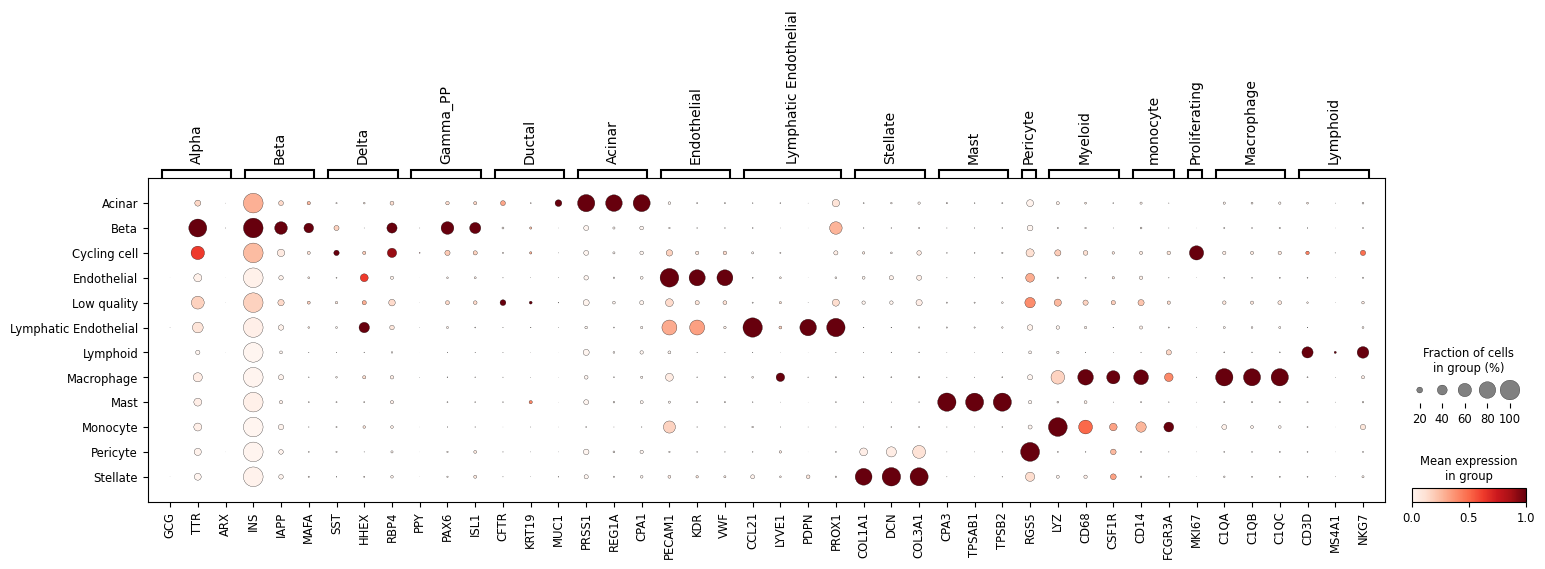

In [94]:
sc.pl.dotplot(
    adata, pancreas_markers ,
    groupby='cell_type',
    standard_scale='var')

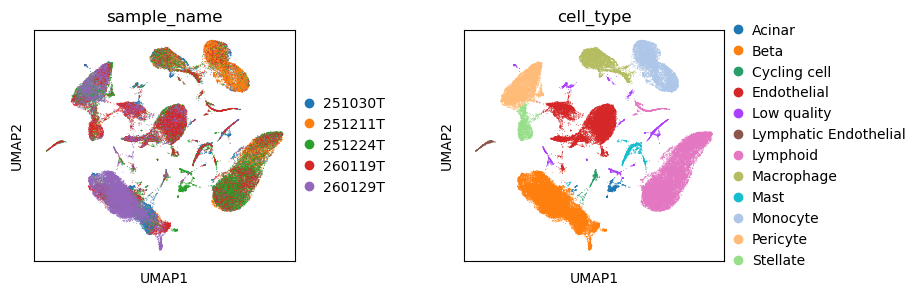

In [95]:
with plt.rc_context({'figure.figsize': (3, 3)}):
    sc.pl.umap(adata,color=['sample_name','cell_type'],wspace=0.5)

In [96]:
adata.write_h5ad('h5ad/islet_raw_annotated.h5ad',compression='gzip')

# Clean cell

In [108]:
adata = adata.raw.to_adata()

In [113]:
adata.X.max()

17387.0

In [106]:
adata.obs['cell_type'].value_counts()

cell_type
Beta                     18855
Lymphoid                 17628
Endothelial              11338
Monocyte                  7064
Pericyte                  6985
Macrophage                4340
Stellate                  1841
Low quality               1776
Mast                      1640
Acinar                     582
Lymphatic Endothelial      550
Cycling cell               305
Name: count, dtype: int64

In [114]:
adata = adata[adata.obs['cell_type'] != 'Low quality']

In [115]:
adata = run_umap(adata,batch_key='sample_name')

2026-03-04 12:28:53,262 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-03-04 12:29:01,147 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-03-04 12:29:01,514 - harmonypy - INFO - Iteration 1 of 20
2026-03-04 12:29:26,680 - harmonypy - INFO - Iteration 2 of 20
2026-03-04 12:29:51,149 - harmonypy - INFO - Iteration 3 of 20
2026-03-04 12:30:16,042 - harmonypy - INFO - Iteration 4 of 20
2026-03-04 12:30:40,620 - harmonypy - INFO - Iteration 5 of 20
2026-03-04 12:31:04,801 - harmonypy - INFO - Converged after 5 iterations


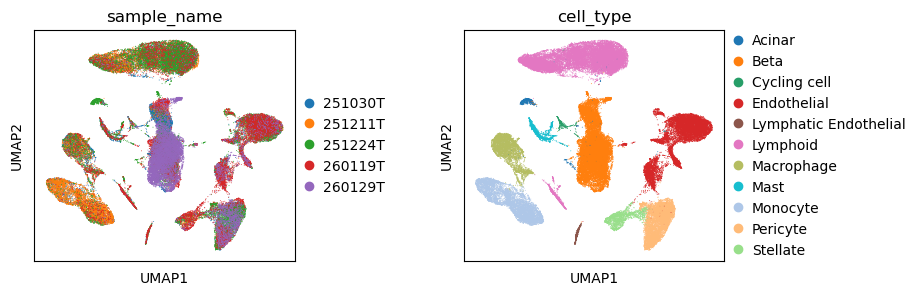

In [116]:
with plt.rc_context({'figure.figsize': (3, 3)}):
    sc.pl.umap(adata,color=['sample_name','cell_type'],wspace=0.5)

In [119]:
adata = adata.raw.to_adata()

In [120]:
adata.X.max()

17387.0

## Endothelial

In [197]:
enco_cell = adata[adata.obs['cell_type'] == 'Endothelial'].copy()

In [198]:
enco_cell = run_umap(enco_cell,batch_key='sample_name')

2026-03-04 13:04:45,873 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-03-04 13:04:46,874 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-03-04 13:04:46,917 - harmonypy - INFO - Iteration 1 of 20
2026-03-04 13:04:48,922 - harmonypy - INFO - Iteration 2 of 20
2026-03-04 13:04:50,866 - harmonypy - INFO - Iteration 3 of 20
2026-03-04 13:04:52,871 - harmonypy - INFO - Iteration 4 of 20
2026-03-04 13:04:54,759 - harmonypy - INFO - Iteration 5 of 20
2026-03-04 13:04:56,807 - harmonypy - INFO - Iteration 6 of 20
2026-03-04 13:04:59,379 - harmonypy - INFO - Iteration 7 of 20
2026-03-04 13:05:00,972 - harmonypy - INFO - Iteration 8 of 20
2026-03-04 13:05:02,408 - harmonypy - INFO - Iteration 9 of 20
2026-03-04 13:05:03,692 - harmonypy - INFO - Iteration 10 of 20
2026-03-04 13:05:04,582 - harmonypy - INFO - Iteration 11 of 20
2026-03-04 13:05:05,865 - harmonypy - INFO - Iteration 12 of 20
2026-03-04 13:05:06,909 - harmonypy - INFO - Converged after

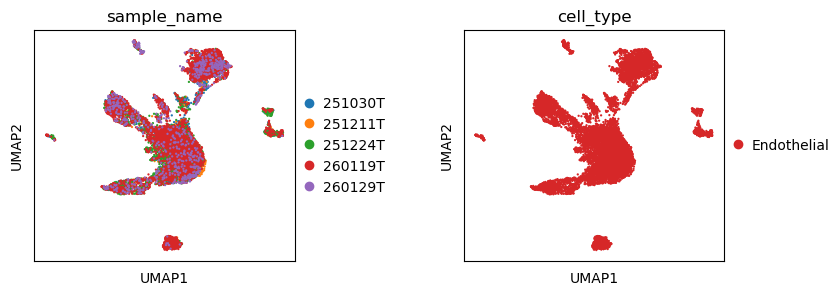

In [199]:
with plt.rc_context({'figure.figsize': (3, 3)}):
    sc.pl.umap(enco_cell,color=['sample_name','cell_type'],wspace=0.5)

In [200]:
sc.tl.leiden(enco_cell, resolution=0.1)

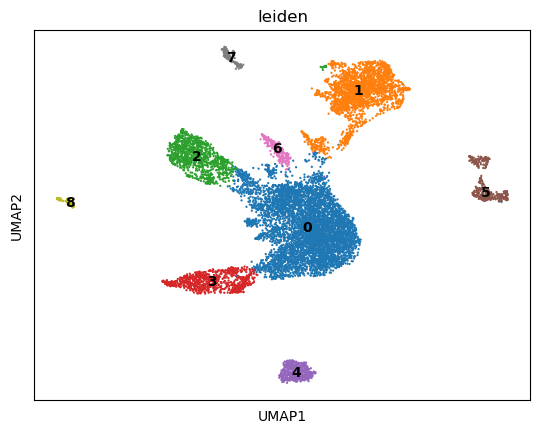

In [203]:
sc.pl.umap(enco_cell,color = 'leiden',legend_loc='on data')

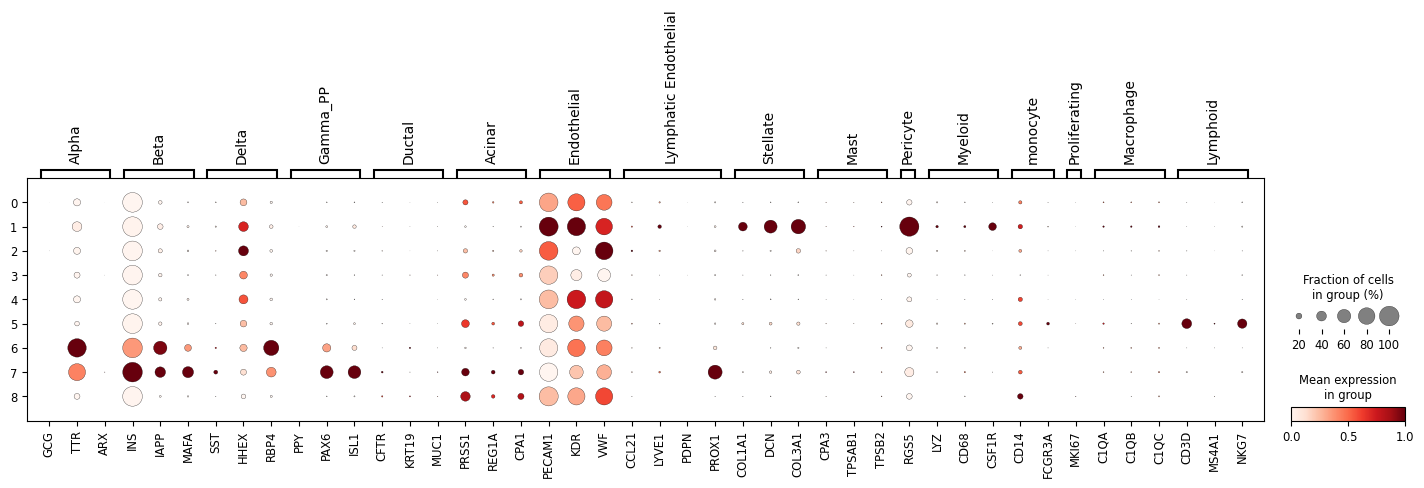

In [202]:
sc.pl.dotplot(
    enco_cell, pancreas_markers, 
    groupby='leiden',
    standard_scale='var')

In [204]:
enco_cell.X.max()

106.47066

In [205]:
enco_cell = enco_cell.raw.to_adata()
enco_cell.raw = enco_cell

In [206]:
enco_cell = enco_cell[enco_cell.obs['leiden'].isin(['0','2','3'])]

In [209]:
enco_cell.X.max()

1408.0

In [208]:
enco_cell.write('h5ad/islet_endo_cell.h5ad',compression='gzip')

## Lymphoid

In [216]:
Lymphoid_cell = adata[adata.obs['cell_type'] == 'Lymphoid'].copy()

In [217]:
Lymphoid_cell = run_umap(Lymphoid_cell,batch_key='sample_name')

2026-03-04 13:07:16,662 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-03-04 13:07:18,183 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-03-04 13:07:18,253 - harmonypy - INFO - Iteration 1 of 20
2026-03-04 13:07:21,915 - harmonypy - INFO - Iteration 2 of 20
2026-03-04 13:07:25,651 - harmonypy - INFO - Iteration 3 of 20
2026-03-04 13:07:29,601 - harmonypy - INFO - Iteration 4 of 20
2026-03-04 13:07:32,625 - harmonypy - INFO - Iteration 5 of 20
2026-03-04 13:07:34,428 - harmonypy - INFO - Iteration 6 of 20
2026-03-04 13:07:36,365 - harmonypy - INFO - Iteration 7 of 20
2026-03-04 13:07:38,220 - harmonypy - INFO - Iteration 8 of 20
2026-03-04 13:07:39,859 - harmonypy - INFO - Iteration 9 of 20
2026-03-04 13:07:41,476 - harmonypy - INFO - Iteration 10 of 20
2026-03-04 13:07:42,982 - harmonypy - INFO - Converged after 10 iterations


In [218]:
sc.tl.leiden(Lymphoid_cell, resolution=0.3)

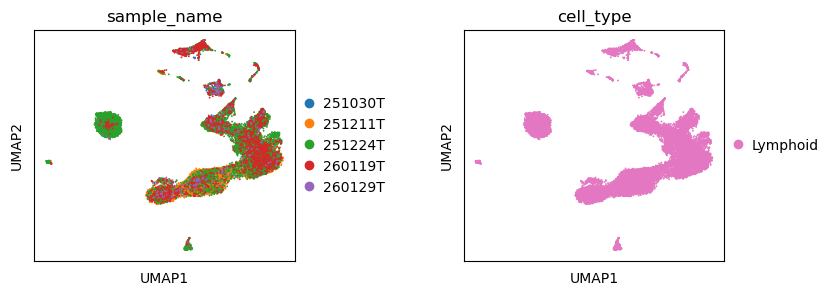

In [219]:
with plt.rc_context({'figure.figsize': (3, 3)}):
    sc.pl.umap(Lymphoid_cell,color=['sample_name','cell_type'],wspace=0.5)

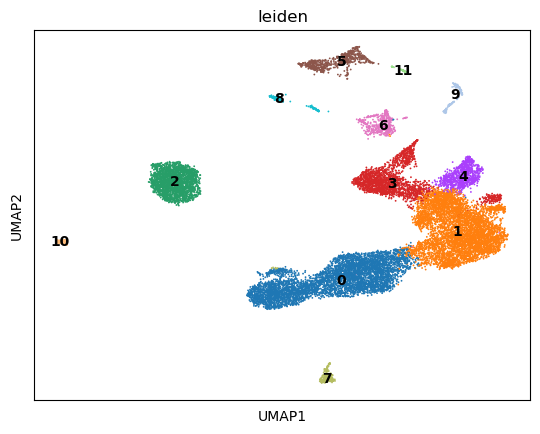

In [223]:
sc.pl.umap(Lymphoid_cell,color = 'leiden',legend_loc='on data')

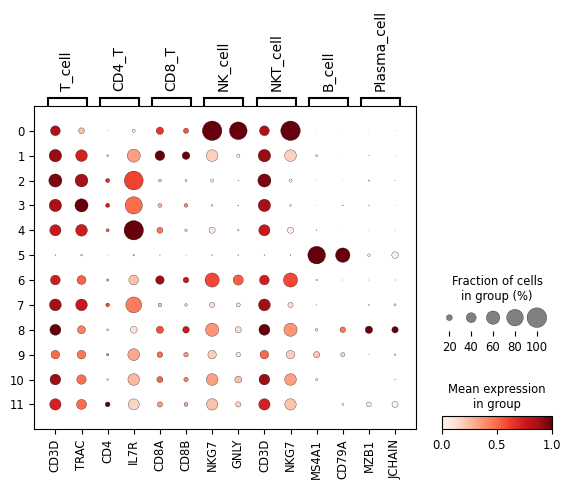

In [224]:
lymphoid_markers = {
    "T_cell": ["CD3D", "TRAC"],
    "CD4_T": ["CD4", "IL7R"],
    "CD8_T": ["CD8A", "CD8B"],
    "NK_cell": ["NKG7", "GNLY"],
    "NKT_cell": ["CD3D", "NKG7"],
    "B_cell": ["MS4A1", "CD79A"],
    "Plasma_cell": ["MZB1", "JCHAIN"]
}
sc.pl.dotplot(
    Lymphoid_cell, lymphoid_markers, 
    groupby='leiden',
    standard_scale='var')

In [225]:
Lymphoid_cell = Lymphoid_cell.raw.to_adata()
Lymphoid_cell.raw = Lymphoid_cell

In [227]:
Lymphoid_cell.X.max()

17387.0

In [228]:
Lymphoid_leiden_ct = {
    "B": [5],
    "T": [1,3,4],
    "NK": [0],
    "Low quality": [2,6,7,8,9,10,11]
}
Lymphoid_cluster2celltype = {
    str(cluster): str(ct)
    for ct, clusters in Lymphoid_leiden_ct.items()
    for cluster in clusters
}
Lymphoid_cell.obs['cell_type'] = (
    Lymphoid_cell.obs['leiden']
    .map(Lymphoid_cluster2celltype)
    .astype('category')
)

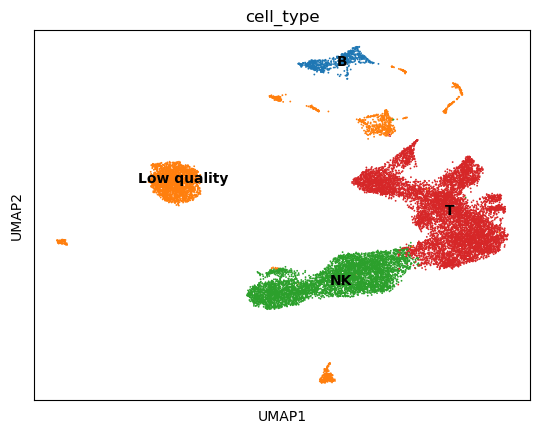

In [229]:
sc.pl.umap(Lymphoid_cell,color = 'cell_type',legend_loc='on data')

In [230]:
Lymphoid_cell = Lymphoid_cell[Lymphoid_cell.obs['cell_type'] != 'Low quality'].copy()
Lymphoid_cell = Lymphoid_cell.raw.to_adata()

In [231]:
Lymphoid_cell.write('h5ad/islet_Lymphoid_cell.h5ad',compression='gzip')

## Merge left cells

In [186]:
left_cell = adata[~adata.obs['cell_type'].isin(['Lymphoid','Endothelial'])].copy()

In [237]:
adata_final = sc.concat([left_cell,enco_cell,Lymphoid_cell])

In [238]:
adata_final = run_umap(adata_final,batch_key='sample_name')

2026-03-04 13:11:18,290 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-03-04 13:11:26,001 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-03-04 13:11:26,334 - harmonypy - INFO - Iteration 1 of 20
2026-03-04 13:11:48,212 - harmonypy - INFO - Iteration 2 of 20
2026-03-04 13:12:09,344 - harmonypy - INFO - Iteration 3 of 20
2026-03-04 13:12:30,308 - harmonypy - INFO - Iteration 4 of 20
2026-03-04 13:12:52,823 - harmonypy - INFO - Iteration 5 of 20
2026-03-04 13:13:14,205 - harmonypy - INFO - Iteration 6 of 20
2026-03-04 13:13:36,881 - harmonypy - INFO - Iteration 7 of 20
2026-03-04 13:13:57,999 - harmonypy - INFO - Converged after 7 iterations


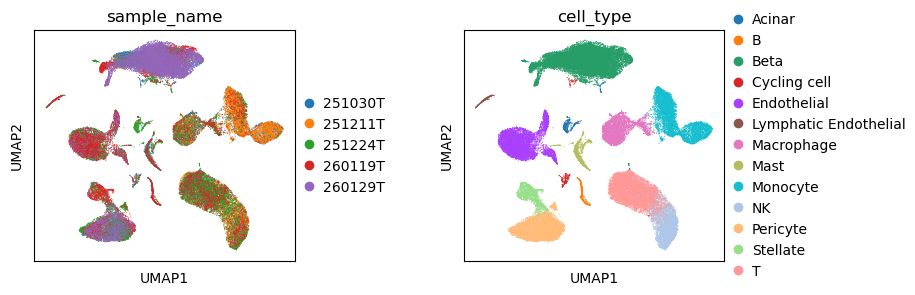

In [240]:
with plt.rc_context({'figure.figsize': (3, 3)}):
    sc.pl.umap(adata_final,color=['sample_name','cell_type'],wspace=0.5)

In [245]:
sc.tl.leiden(adata_final,flavor = 'igraph', resolution=3)

In [249]:
adata_final[adata_final.obs['cell_type'] == 'Cycling cell'].obs['leiden'].value_counts()

leiden
24    242
3      49
38     10
53      2
12      1
23      1
Name: count, dtype: int64

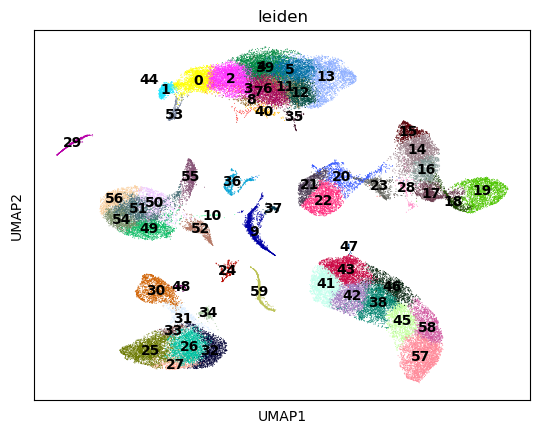

In [251]:
sc.pl.umap(adata_final,color='leiden',legend_loc='on data')

In [252]:
adata_final = adata_final[~adata_final.obs['leiden'].isin(['3','23','47','10','34','35','31','47','48','52','44','53','55'])]

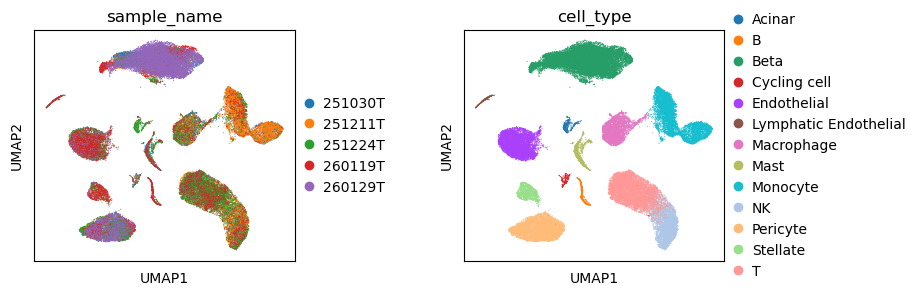

In [253]:
with plt.rc_context({'figure.figsize': (3, 3)}):
    sc.pl.umap(adata_final,color=['sample_name','cell_type'],wspace=0.5)

In [259]:
adata_final.obs['cell_type'].cat.categories

Index(['Acinar', 'B', 'Beta', 'Cycling cell', 'Endothelial',
       'Lymphatic Endothelial', 'Macrophage', 'Mast', 'Monocyte', 'NK',
       'Pericyte', 'Stellate', 'T'],
      dtype='object')

In [274]:
adata_final = sc.read_h5ad('h5ad/islet_final_annotated.h5ad')

In [278]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['savefig.dpi'] = 300

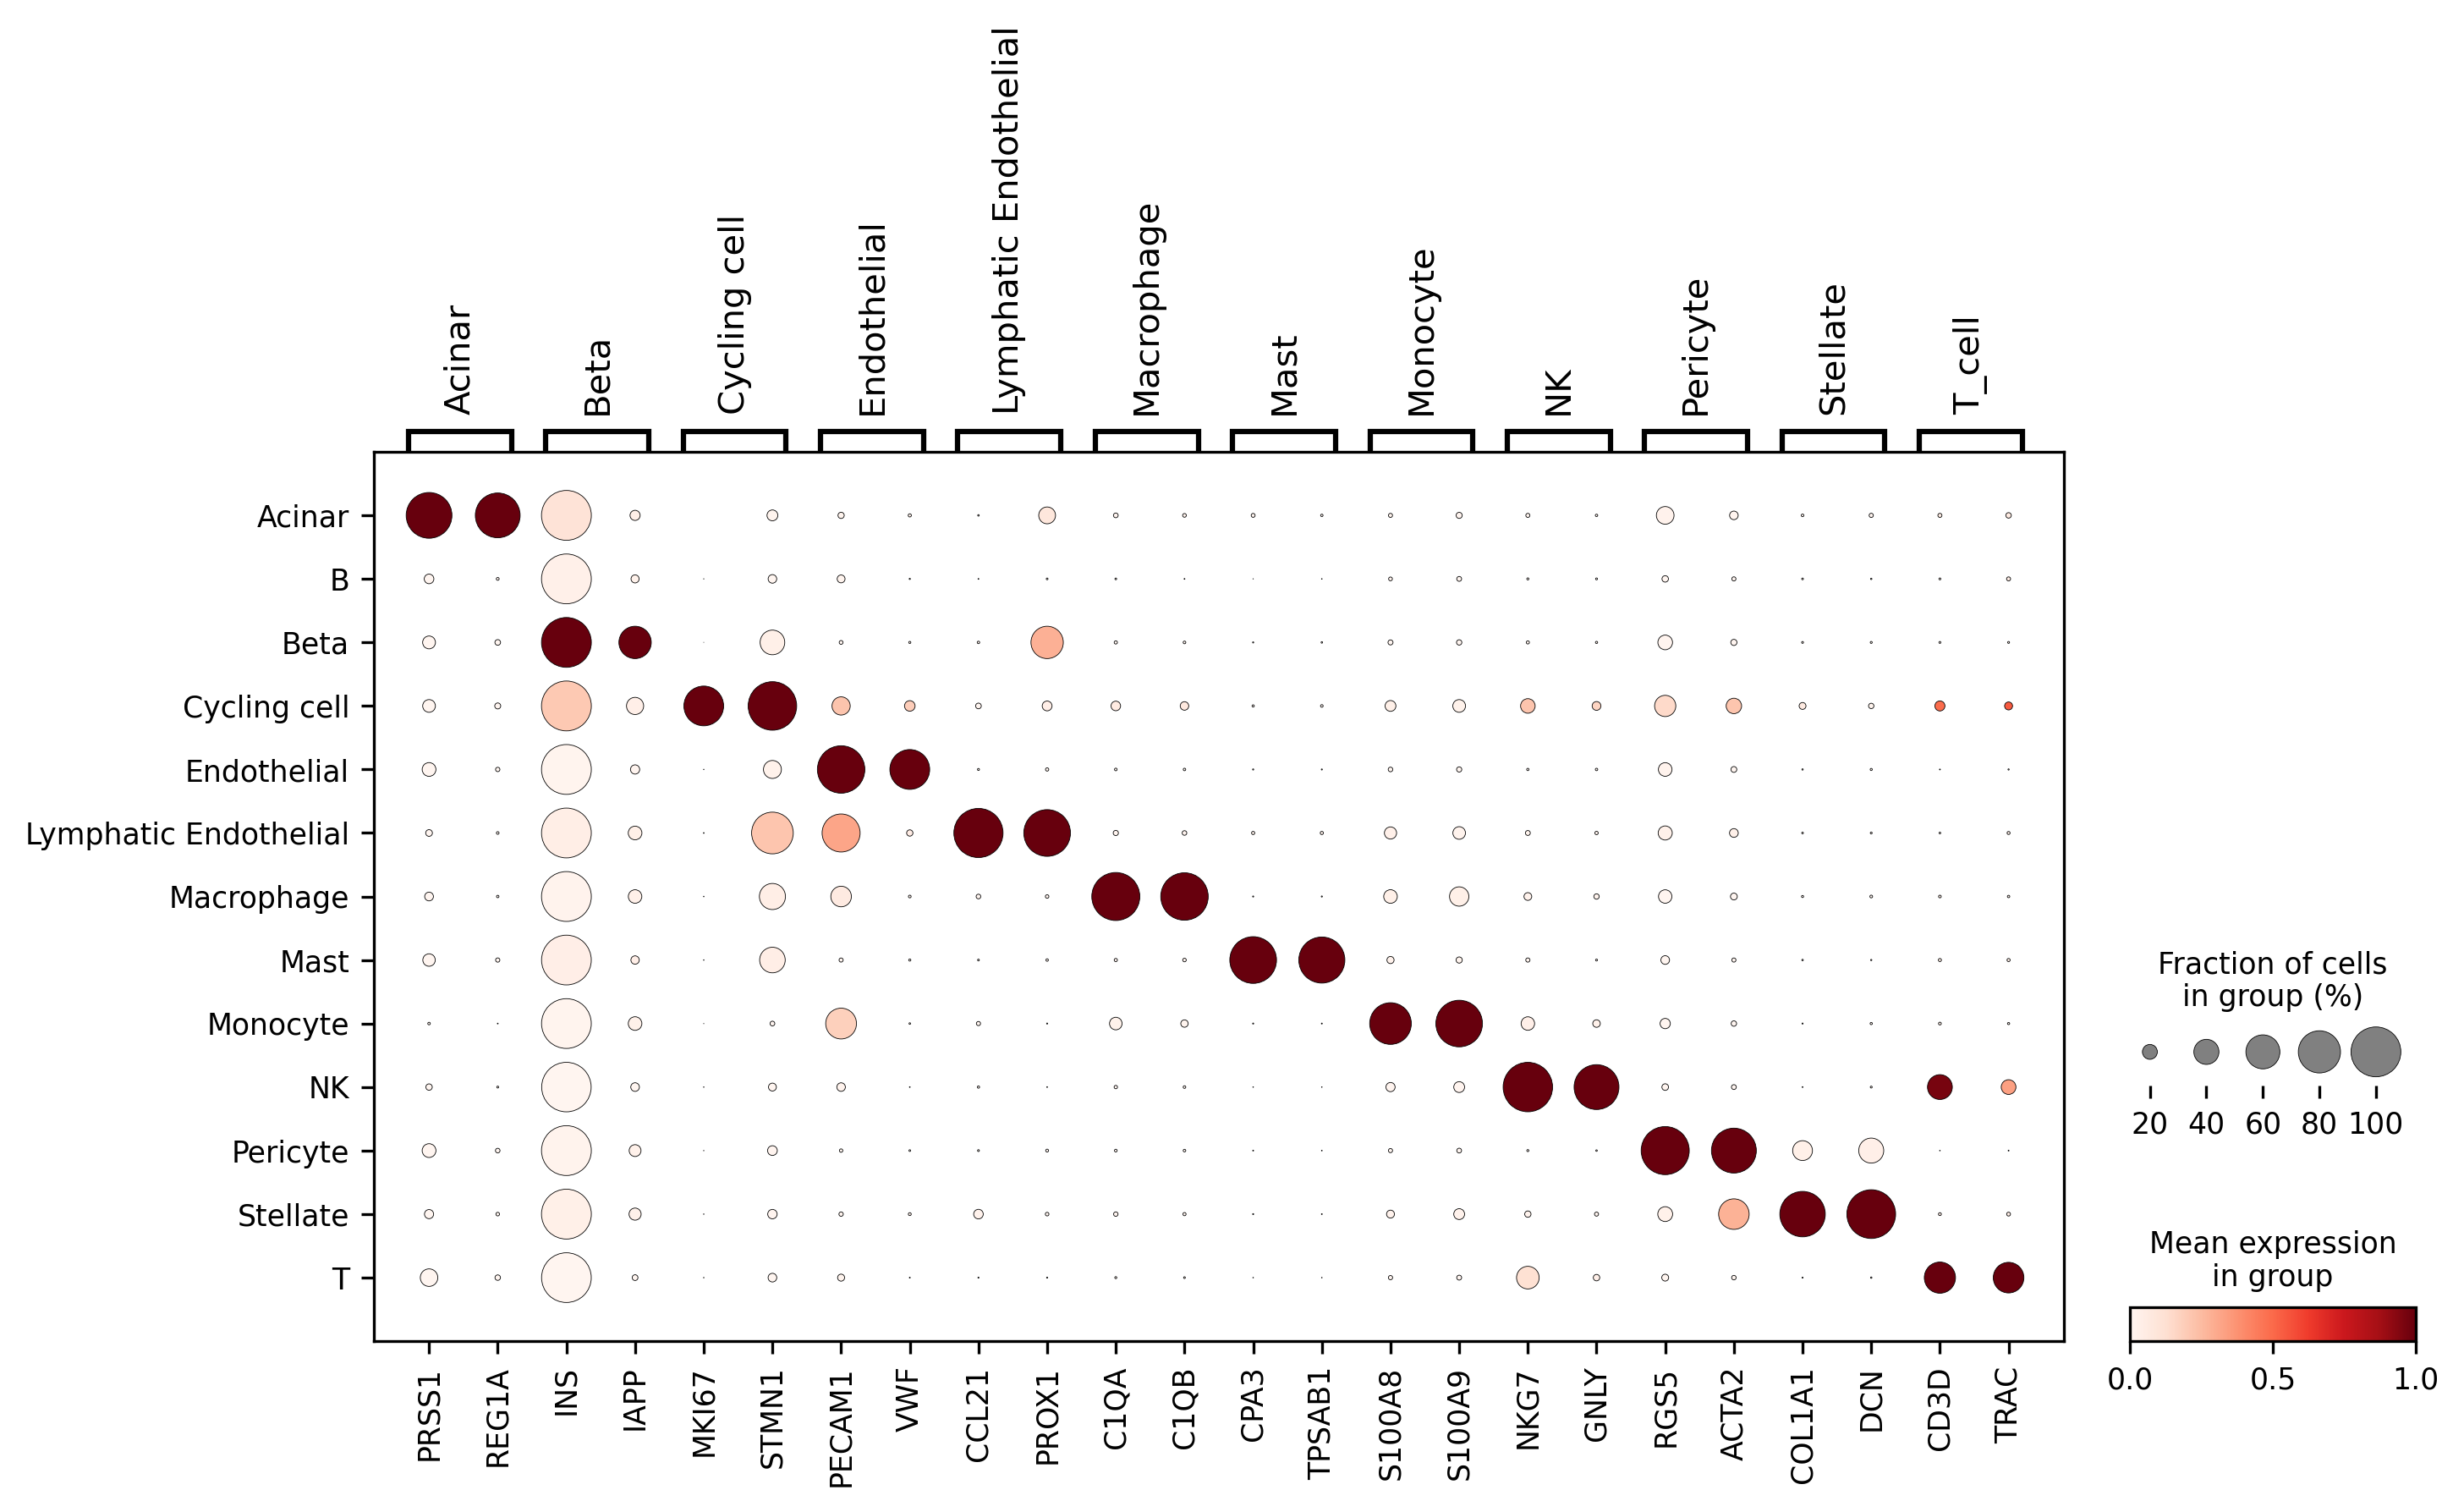

In [280]:
final_markers = {
    "Acinar": ["PRSS1", "REG1A"],
    "Beta": ["INS", "IAPP"],
    'Cycling cell': ["MKI67",'STMN1'],
    "Endothelial": ["PECAM1", "VWF"],
    "Lymphatic Endothelial":["CCL21", "PROX1"],
    "Macrophage": ["C1QA", "C1QB"],
    "Mast":["CPA3", "TPSAB1"],
    'Monocyte':['S100A8','S100A9'],
    "NK":["NKG7", "GNLY"],
    'Pericyte':['RGS5','ACTA2'],
    "Stellate": ["COL1A1", "DCN"],
    "T_cell": ["CD3D", "TRAC"]
}
    
sc.pl.dotplot(
    adata_final, final_markers ,
    groupby='cell_type',
    standard_scale='var',
    save='scRNA_marker.pdf')

In [254]:
adata_final.write_h5ad('h5ad/islet_final_annotated.h5ad',compression='gzip')